In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("jobs-and-job-description/job_title_des.csv")

# Keep relevant columns
df = df[['Job Title', 'Job Description']].dropna()
df.columns = ['label', 'text']

print("Dataset Shape:", df.shape)
print("\nSample Data:\n", df.head())


Dataset Shape: (2277, 2)

Sample Data:
                   label                                               text
0     Flutter Developer  We are looking for hire experts flutter develo...
1      Django Developer  PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2      Machine Learning  Data Scientist (Contractor)\n\nBangalore, IN\n...
3         iOS Developer  JOB DESCRIPTION:\n\nStrong framework outside o...
4  Full Stack Developer  job responsibility full stack engineer – react...


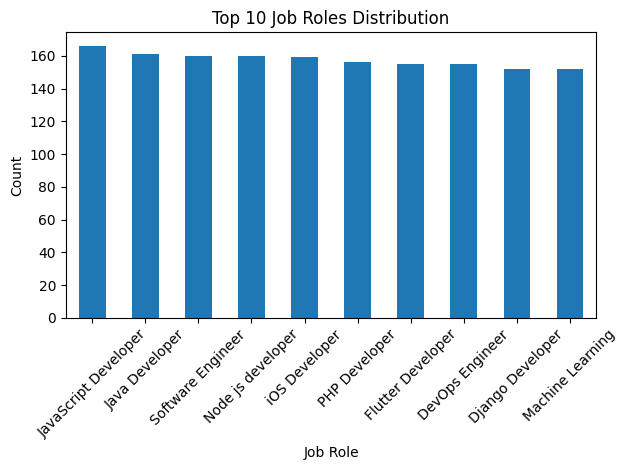

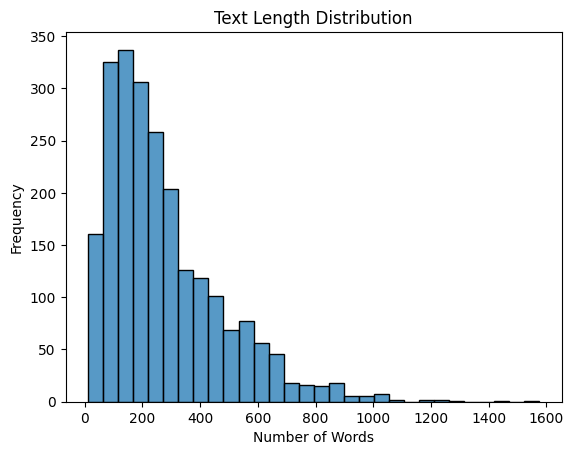

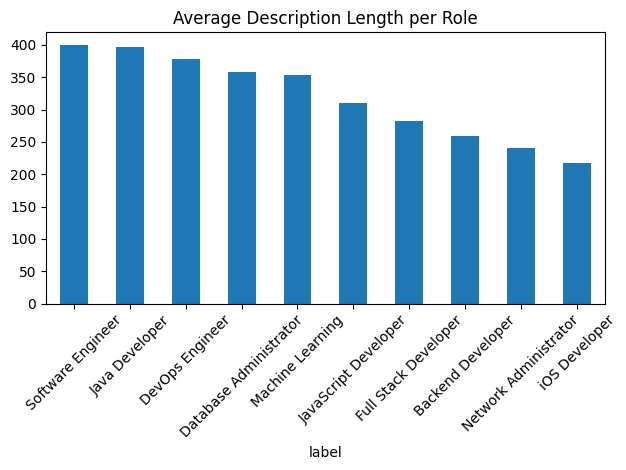

In [4]:

# -----------------------------
# 2. EDA (EXPLORATORY DATA ANALYSIS)
# -----------------------------

# Class distribution
plt.figure()
df['label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Job Roles Distribution")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Text length distribution
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

plt.figure()
sns.histplot(df['text_length'], bins=30)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Average text length per class
plt.figure()
df.groupby('label')['text_length'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Description Length per Role")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
# -----------------------------
# 3. REDUCE CLASSES (IMPORTANT)
# -----------------------------
top_roles = df['label'].value_counts().head(10).index
df = df[df['label'].isin(top_roles)]

# -----------------------------
# 4. FEATURE EXTRACTION (TF-IDF)
# -----------------------------
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(df['text'])
y = df['label']


In [6]:


# -----------------------------
# 5. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 6. MODEL TRAINING
# -----------------------------
model = MultinomialNB()
model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [7]:

# -----------------------------
# 7. PREDICTION
# -----------------------------
y_pred = model.predict(X_test)



Accuracy: 0.8259493670886076

Classification Report:

                      precision    recall  f1-score   support

     DevOps Engineer       0.84      0.87      0.85        30
    Django Developer       0.88      0.88      0.88        24
   Flutter Developer       0.76      0.97      0.85        30
      Java Developer       0.77      0.71      0.74        28
JavaScript Developer       0.77      0.61      0.68        33
    Machine Learning       1.00      0.87      0.93        38
   Node js developer       0.95      0.87      0.91        47
       PHP Developer       0.85      0.97      0.90        29
   Software Engineer       0.49      0.65      0.56        26
       iOS Developer       0.96      0.84      0.90        31

            accuracy                           0.83       316
           macro avg       0.83      0.82      0.82       316
        weighted avg       0.84      0.83      0.83       316



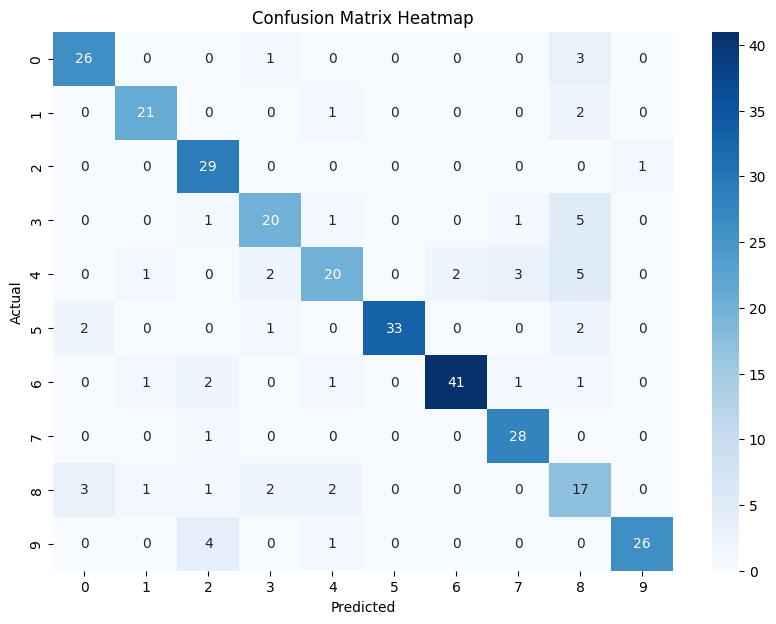

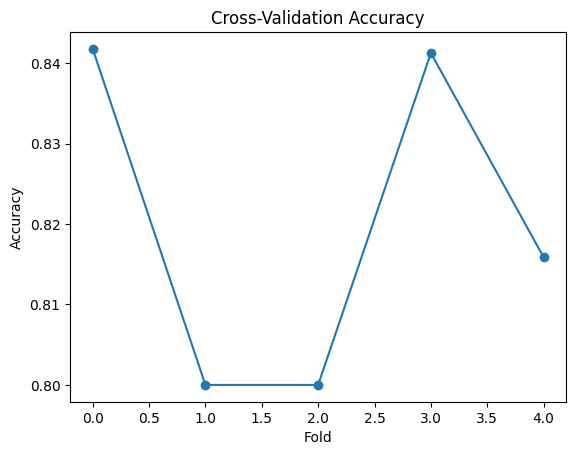

Cross-validation scores: [0.84177215 0.8        0.8        0.84126984 0.81587302]
Mean CV Accuracy: 0.8197830018083183


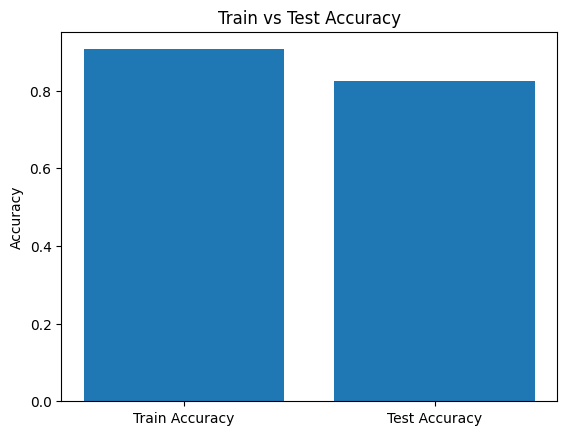

In [8]:

# -----------------------------
# 8. EVALUATION
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 9. CONFUSION MATRIX (HEATMAP)
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 10. CROSS VALIDATION
# -----------------------------
scores = cross_val_score(model, X, y, cv=5)

plt.figure()
plt.plot(scores, marker='o')
plt.title("Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

print("Cross-validation scores:", scores)
print("Mean CV Accuracy:", scores.mean())

# -----------------------------
# 11. TRAIN vs TEST ACCURACY GRAPH
# -----------------------------
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

plt.figure()
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.show()


In [10]:

# -----------------------------
# 12. PREDICTION FUNCTION
# -----------------------------
def predict_job(text):
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

print("\nExample Prediction:")
print(predict_job("I build model and ai"))


Example Prediction:
Machine Learning


In [12]:

import joblib

# Save model
joblib.dump(model, "job_model.pkl")

# Save vectorizer
joblib.dump(vectorizer, "vectorizer.pkl")

print("✅ Model and vectorizer saved")

✅ Model and vectorizer saved


In [ ]:
import joblib

# Load model
model = joblib.load("job_model.pkl")

# Load vectorizer
vectorizer = joblib.load("vectorizer.pkl")

In [13]:
def predict_job(text):
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

print(predict_job("I develop web apps using React"))

JavaScript Developer
